# Exploratory Data Analysis (EDA)

This notebook explores the credit card default dataset to understand:
- distribution of variables  
- relationships between features  
- patterns associated with default behavior  

The goal is to identify key insights that will guide feature engineering.

### Load Clean Dataset

We load the cleaned dataset prepared in the previous notebook.

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("credit_clean.csv")

print("Shape:", df.shape)
df.head()

Shape: (30000, 24)


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Dataset Overview

The dataset contains 30,000 observations and 24 features.

Each row represents a credit card customer, including demographic details, credit usage, repayment history, and default status.

The preview of the data shows that:
- financial variables (bill amounts, payments) vary widely
- repayment status variables (PAY_X) include both negative and positive values, indicating different repayment behaviors

The dataset appears structured and ready for further analysis.

---
### Target Variable Distribution

We analyze the distribution of the target variable (`default`) to understand class balance.

In [6]:
df["default"].value_counts()

default
0    23364
1     6636
Name: count, dtype: int64

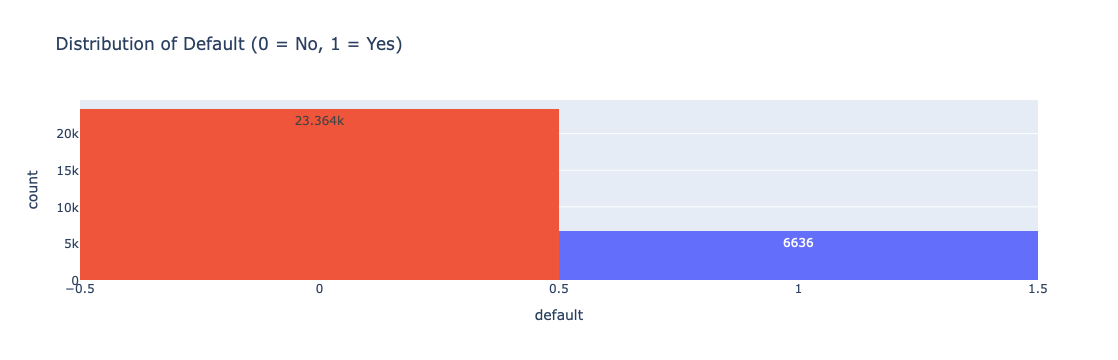

In [7]:
fig = px.histogram(
    df,
    x="default",
    color="default",
    text_auto=True,
    title="Distribution of Default (0 = No, 1 = Yes)"
)

fig.update_layout(showlegend=False)

fig.show()

### Target Variable Distribution

The dataset shows an imbalanced distribution of the target variable:

- Non-default (0): 23,364 customers (~78%)
- Default (1): 6,636 customers (~22%)

This indicates that most customers do not default, while a smaller proportion do.

The class imbalance is important to consider during modeling, as it may affect model performance and evaluation.

---
### Credit Limit Distribution

We analyze how credit limits are distributed across customers.

This helps us understand customer financial capacity.

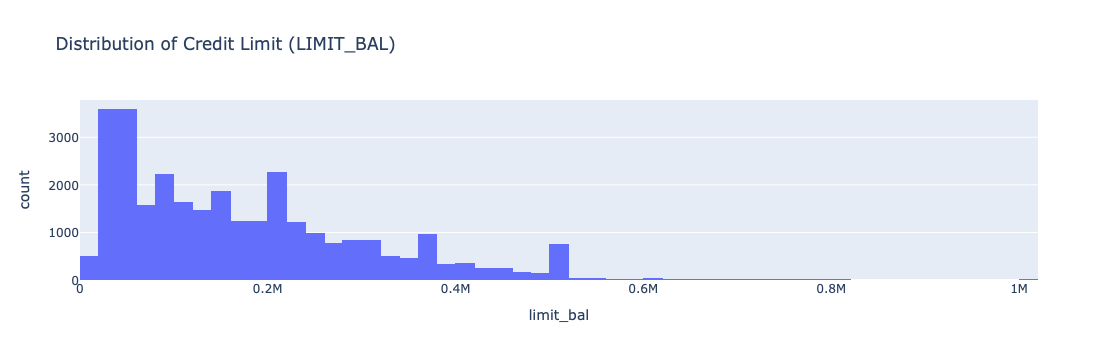

In [10]:
fig = px.histogram(
    df,
    x="limit_bal",
    nbins=50,
    title="Distribution of Credit Limit (LIMIT_BAL)"
)

fig.show()

### Credit Limit Distribution

The distribution of credit limits is right-skewed, with most customers having lower to moderate credit limits.

A smaller number of customers have very high credit limits, creating a long tail in the distribution.

This indicates that while most customers operate within modest credit ranges, a few high-value customers have significantly larger financial capacity.

---
### Age Distribution

We analyze the age distribution of customers to understand demographic patterns.

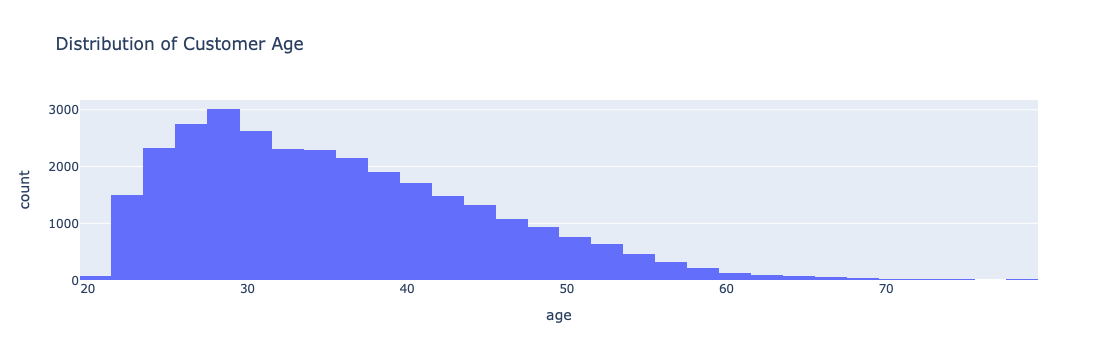

In [13]:
fig = px.histogram(
    df,
    x="age",
    nbins=40,
    title="Distribution of Customer Age"
)

fig.show()

### Age Distribution

The age distribution shows that most customers fall within the 25–40 age range.

The distribution is slightly right-skewed, with fewer customers in older age groups.

This indicates that the dataset is dominated by younger to middle-aged individuals, with a gradual decline in frequency as age increases.

---
### Average Bill Amount

We calculate the average bill amount across 6 months to understand customer spending behavior.

In [16]:
bill_cols = [f"bill_amt{i}" for i in range(1, 7)]

df["avg_bill"] = df[bill_cols].mean(axis=1)

df[["avg_bill"]].head()

,avg_bill
0,1284.000000
1,2846.166667
2,16942.166667
3,38555.666667
4,18223.166667


### Average Bill Amount

The average bill amount summarizes customer spending behavior across six months.

The values vary significantly across customers, indicating differences in spending levels.

This feature provides a more stable and aggregated measure compared to individual monthly bill amounts, making it useful for analysis and modeling.

---
### Average Bill Amount vs Default

We compare the average bill amount between customers who default and those who do not.

This helps identify whether higher spending is associated with default risk.

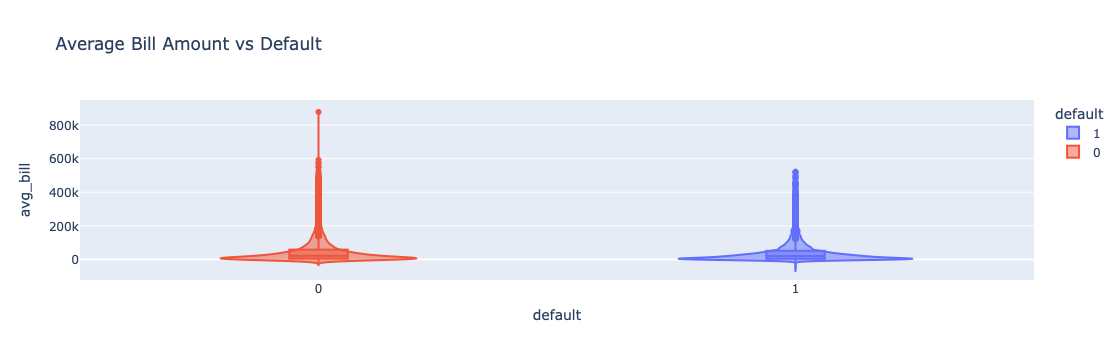

In [19]:
fig = px.violin(
    df,
    x="default",
    y="avg_bill",
    color="default",
    box=True,
    points="outliers",
    title="Average Bill Amount vs Default"
)

fig.show()

### Average Bill Amount vs Default

The distribution of average bill amounts shows substantial overlap between defaulters and non-defaulters.

Both groups have similar median values and spread, indicating that spending levels alone do not strongly differentiate customers who default from those who do not.

Although non-defaulters show slightly higher variability and some extreme high values, the overall distributions are quite similar.

This suggests that average bill amount is not a strong standalone predictor of default risk.

---
### Average Payment Amount

We calculate the average payment made by customers over 6 months.

This helps analyze repayment behavior.

In [22]:
pay_cols = [f"pay_amt{i}" for i in range(1, 7)]

df["avg_payment"] = df[pay_cols].mean(axis=1)

df[["avg_payment"]].head()

,avg_payment
0,114.833333
1,833.333333
2,1836.333333
3,1398.000000
4,9841.500000


### Average Payment Amount

The average payment amount represents how much customers repay on average over six months.

The values vary widely across customers, indicating differences in repayment behavior.

This feature provides a more consistent and aggregated measure of payment activity compared to individual monthly payments, making it useful for analyzing repayment patterns.

---
### Average Payment vs Default

This visualization compares average payment behavior between customers who default and those who do not.

This helps evaluate whether repayment behavior is a strong predictor of default.

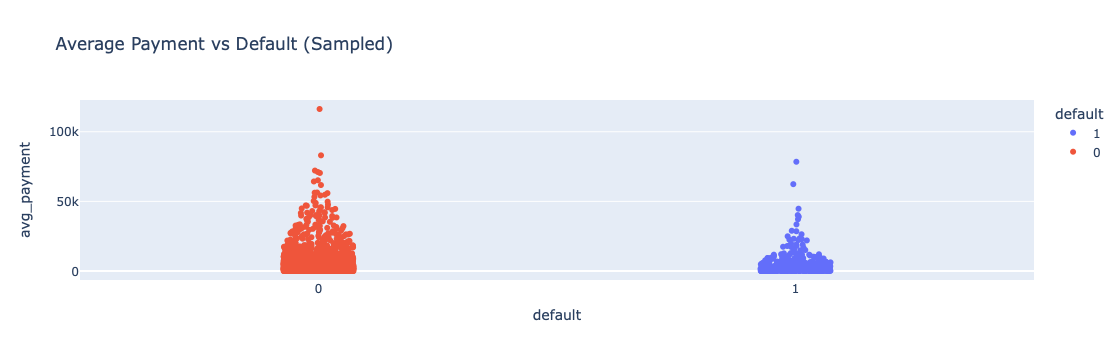

In [25]:
fig = px.strip(
    df.sample(3000),  # sample to avoid overload
    x="default",
    y="avg_payment",
    color="default",
    title="Average Payment vs Default (Sampled)"
)
fig.show()

### Average Payment vs Default

The scatter plot shows the distribution of average payments for defaulters and non-defaulters.

Non-defaulters generally make higher and more varied payments, while defaulters tend to have lower payment amounts concentrated near the lower range.

Although there is some overlap between the two groups, customers with consistently low payments appear more likely to default.

This suggests that repayment behavior has moderate predictive value for default risk.

---
### Repayment Behavior Features

The PAY_X variables capture repayment delay status across months.

We create behavioral features:
- average delay
- maximum delay
- number of delayed months

These features are expected to strongly influence default.

In [28]:
pay_status_cols = ["pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"]

# Average delay
df["avg_delay"] = df[pay_status_cols].mean(axis=1)

# Maximum delay
df["max_delay"] = df[pay_status_cols].max(axis=1)

# Count of months with delay (>0 means delay)
df["delay_count"] = (df[pay_status_cols] > 0).sum(axis=1)

df[["avg_delay", "max_delay", "delay_count"]].head()

,avg_delay,max_delay,delay_count
0,-0.333333,2,2
1,0.500000,2,2
2,0.000000,0,0
3,0.000000,0,0
4,-0.333333,0,0


### Repayment Behavior Features

New behavioral features were created using repayment status variables across six months.

- **Average delay** captures overall repayment behavior  
- **Maximum delay** reflects the worst repayment instance  
- **Delay count** measures how frequently delays occur  

These features summarize repayment patterns more effectively than individual monthly values.

They are expected to be strong predictors of default, as consistent or severe delays indicate higher financial risk.

---
### Repayment Delay vs Default

This visualization shows how repayment delays relate to default behavior.

Behavioral features such as delay frequency and severity are expected to strongly distinguish defaulters from non-defaulters.

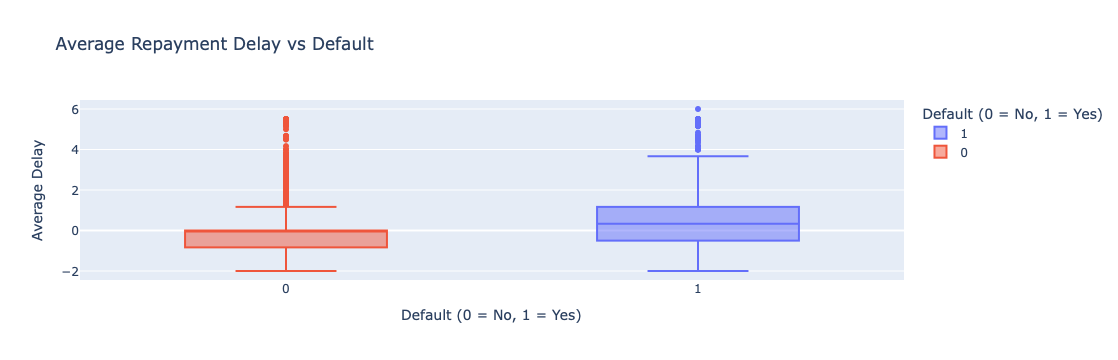

In [31]:
fig = px.box(
    df,
    x="default",
    y="avg_delay",
    color="default",
    title="Average Repayment Delay vs Default",
    labels={"default": "Default (0 = No, 1 = Yes)", "avg_delay": "Average Delay"},
)
fig.show()

### Repayment Delay vs Default

This plot shows a clear difference in repayment behavior between defaulters and non-defaulters.

- Customers who **did not default (0)** tend to have **negative or near-zero delays**, indicating timely or early payments  
- Customers who **defaulted (1)** show **higher average delays**, with a positive median  

Key observations:
- Median delay for defaulters is **above 0**, while non-defaulters are centered **below 0**
- Defaulters also show **greater spread and higher extreme values**
- There is a noticeable shift in distribution between the two groups  

This suggests that **repayment delay is a strong predictor of default**, where frequent or severe delays significantly increase the likelihood of default.

---
### Delay vs Payment Behavior

This scatter plot explores the relationship between repayment delays and payment behavior.

Each point represents a customer, with color indicating default status.

This visualization helps identify patterns between:
- repayment delays (behavioral risk)
- payment amounts (financial activity)

Customers with higher delays and lower payments are more likely to default, highlighting the importance of behavioral features in predicting credit risk.

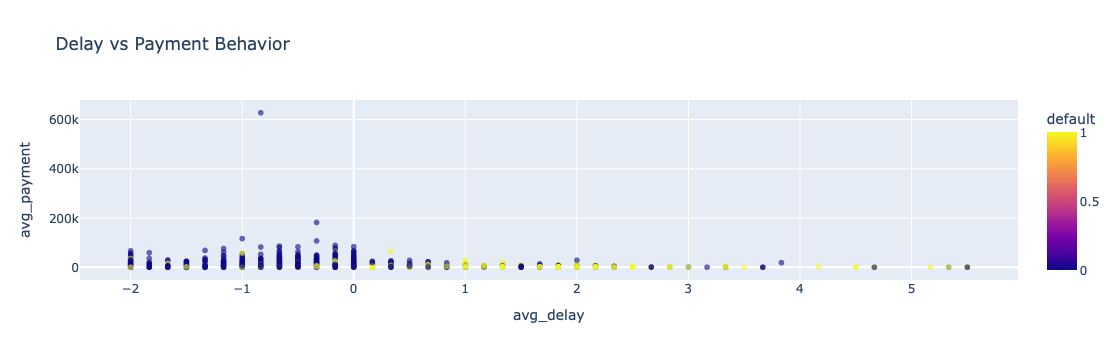

In [34]:
fig = px.scatter(
    df.sample(5000),
    x="avg_delay",
    y="avg_payment",
    color="default",
    title="Delay vs Payment Behavior",
    opacity=0.6
)

fig.show()

### Delay vs Payment Behavior

This scatter plot highlights the relationship between repayment delays and payment behavior.

Key observations:

- Customers with **low or negative delays** (on-time or early payments) show a **wide range of payment amounts**, including higher payments  
- Customers with **higher delays** (positive avg_delay) tend to have **lower payment amounts**  
- Defaulters (1) are more concentrated in regions with:
  - **higher delays**
  - **lower payments**

Patterns observed:

- There is a **negative relationship** between delay and payment behavior  
- As delays increase, payment amounts generally decrease  
- Non-defaulters are more spread out, while defaulters cluster in risky regions  

Conclusion:

This visualization reinforces that **customers who delay payments and pay less are more likely to default**, making these behavioral features highly valuable for predicting credit risk.

---
### Correlation Heatmap

This heatmap shows relationships between key variables.

It helps identify:
- which features are strongly related to default
- redundancy between features
- important predictors for modeling

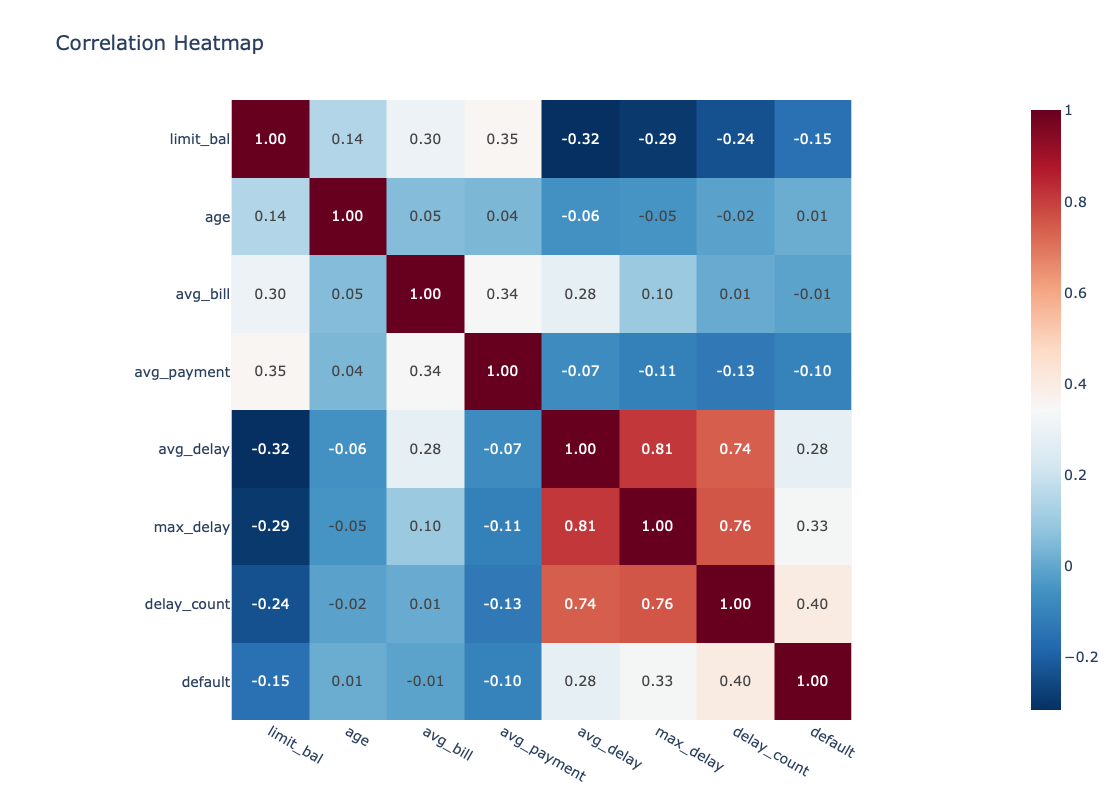

In [37]:
# Select key features only (important!)
eda_cols = [
    "limit_bal", "age",
    "avg_bill", "avg_payment",
    "avg_delay", "max_delay", "delay_count",
    "default"
]

corr = df[eda_cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap"
)

fig.update_layout(
    width=900,
    height=800,
    font=dict(size=14)
)

fig.show()

### Correlation Heatmap

The correlation heatmap highlights relationships between key features and the target variable (default).

Key insights:

**1. Strong predictors of default**
- **delay_count (0.40)** and **max_delay (0.33)** show the highest positive correlation with default  
- **avg_delay (0.28)** is also positively correlated  
➡️ This confirms that **repayment behavior is the strongest indicator of default risk**

**2. Weak financial feature relationships**
- **avg_payment (-0.10)** and **limit_bal (-0.15)** show weak negative correlations with default  
- **avg_bill (-0.01)** has almost no relationship  
➡️ Payment and spending alone are **not strong predictors**

**3. High multicollinearity among delay features**
- **avg_delay, max_delay, and delay_count** are highly correlated (0.74–0.81)  
➡️ These features capture similar information and may be redundant in modeling

**4. Age has minimal impact**
- Correlation with default is close to **0 (0.01)**  
➡️ Age is not a meaningful predictor in this dataset  

### Conclusion

- Behavioral features (**repayment delays**) are the most important drivers of default  
- Financial magnitude features (bill/payment amounts) have weaker predictive power  
- Feature selection or dimensionality reduction may be needed due to multicollinearity among delay variables  

---
## Feature Engineering (Finalizing)

In this step, we finalize features for machine learning.

Goals:
- Remove redundant variables
- Keep meaningful engineered features
- Prepare input (X) and target (y)

Based on EDA, repayment behavior features are the most important predictors.

In [40]:
bill_cols = [f"bill_amt{i}" for i in range(1, 7)]
pay_cols = [f"pay_amt{i}" for i in range(1, 7)]

df_fe = df.drop(columns=bill_cols + pay_cols).copy()

print("Shape after dropping raw bill/payment columns:", df_fe.shape)
df_fe.head()

Shape after dropping raw bill/payment columns: (30000, 17)


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_bill,avg_payment,avg_delay,max_delay,delay_count
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,1,1284.000000,114.833333,-0.333333,2,2
1,120000,2,2,2,26,-1,2,0,0,0,2,1,2846.166667,833.333333,0.500000,2,2
2,90000,2,2,2,34,0,0,0,0,0,0,0,16942.166667,1836.333333,0.000000,0,0
3,50000,2,2,1,37,0,0,0,0,0,0,0,38555.666667,1398.000000,0.000000,0,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,0,18223.166667,9841.500000,-0.333333,0,0


### Remove Redundant Delay Features

From EDA, avg_delay, max_delay, and delay_count are highly correlated.

To reduce multicollinearity, we remove max_delay and keep:
- avg_delay (severity)
- delay_count (frequency)

In [66]:
df_fe = df_fe.drop(columns=["max_delay"])

print("Shape after removing redundant feature:", df_fe.shape)
df_fe.columns

Shape after removing redundant feature: (30000, 16)


Index(['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6', 'default', 'avg_bill',
       'avg_payment', 'avg_delay', 'delay_count'],
      dtype='object')

### Handle Categorical Variables

We convert categorical variables into numeric form using one-hot encoding.

This allows machine learning models to properly interpret them.

In [69]:
df_fe = pd.get_dummies(
    df_fe,
    columns=["sex", "education", "marriage"],
    drop_first=True
)

print("Shape after encoding:", df_fe.shape)
df_fe.head()

Shape after encoding: (30000, 19)


,limit_bal,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_bill,avg_payment,avg_delay,delay_count,sex_2,education_2,education_3,education_4,marriage_2,marriage_3
0,20000,24,2,2,-1,-1,-2,-2,1,1284.000000,114.833333,-0.333333,2,True,True,False,False,False,False
1,120000,26,-1,2,0,0,0,2,1,2846.166667,833.333333,0.500000,2,True,True,False,False,True,False
2,90000,34,0,0,0,0,0,0,0,16942.166667,1836.333333,0.000000,0,True,True,False,False,True,False
3,50000,37,0,0,0,0,0,0,0,38555.666667,1398.000000,0.000000,0,True,True,False,False,False,False
4,50000,57,-1,0,-1,0,0,0,0,18223.166667,9841.500000,-0.333333,0,False,True,False,False,False,False


### Define Features (X) and Target (y)

We separate the dataset into:

- X → input features  
- y → target variable (default)

This prepares the data for machine learning.

In [72]:
y = df_fe["default"]
X = df_fe.drop(columns=["default"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 18)
y shape: (30000,)


### Train-Test Split

We split the dataset into training and testing sets.

Stratified sampling is used to preserve class distribution.

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (24000, 18)
Test shape: (6000, 18)


### Save Final Feature Engineered Dataset

The dataset is saved after feature engineering.

This version will be used for modeling and deployment.

In [86]:
# Save dataset
df_fe.to_csv("credit_feature_engineered.csv", index=False)

print("Saved file: credit_feature_engineered.csv")
print("Shape:", df_fe.shape)

Saved file: credit_feature_engineered.csv
Shape: (30000, 19)


### Feature Scaling

We standardize the features using StandardScaler.

Important:
- Fit scaler only on training data
- Transform both training and testing data

This prevents data leakage.

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.05686623, -0.26455769,  1.79331103,  1.78019315,  2.65204636,
         1.91181115,  0.2402604 ,  0.25608731,  1.91467196,  0.1351982 ,
         1.72133328,  2.04043134,  0.80844039,  1.06404707, -0.44069047,
        -0.1278524 ,  0.93494465, -0.11288796],
       [-0.13408117, -0.15580369,  0.90294373, -0.72232368, -0.69764249,
        -1.53082598, -1.5372518 , -1.48996255, -0.7112067 , -0.53223878,
        -1.00549757,  0.10594025,  0.80844039, -0.93980805, -0.44069047,
        -0.1278524 ,  0.93494465, -0.11288796],
       [-1.21509034,  1.58426024,  0.90294373,  1.78019315,  0.13977972,
         0.19049259,  0.2402604 ,  0.25608731, -0.57524846, -0.46518545,
         0.69877171,  0.75077061, -1.23694958,  1.06404707, -0.44069047,
        -0.1278524 , -1.06958203, -0.11288796],
       [ 0.40642341, -0.69957367,  0.01257644,  0.1118486 ,  0.13977972,
         0.19049259,  0.2402604 ,  0.25608731,  2.24429029,  0.17220189,
         0.18749092, -0.53889011,  0.80844039, -0.939

### Final Dataset Ready for Modeling

The dataset is now fully prepared for machine learning.

Steps completed:
- Removed redundant features
- Created meaningful engineered features
- Encoded categorical variables
- Split data into train and test sets
- Applied proper feature scaling

The data is now clean, structured, and ready for model training.